# Avaliação e métricas — SOP (PCOS)

Avaliação no **conjunto de teste** e escolha do melhor modelo.

- **Entrada:** `src/db/outputs/polycystic-ovary-syndrome-pcos/03-modelagem-treino/artifacts/modelos_treinados.joblib`
- **Métricas:** acurácia, recall de PCOS (classe 1), F1
- **Saídas:** `metricas_teste.json` e matrizes de confusão


## 1 - Setup e carregamento


In [1]:
from pathlib import Path
import json
import re
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, confusion_matrix

def encontrar_raiz() -> Path:
    atual = Path.cwd().resolve()
    for candidato in [atual, *atual.parents]:
        if (candidato / "src" / "db").is_dir():
            return candidato
    raise FileNotFoundError("Raiz do repositório não encontrada.")

RAIZ = encontrar_raiz()
OUTPUT_BASE = RAIZ / "src/db/outputs/polycystic-ovary-syndrome-pcos"

PASTA_ENTRADA = OUTPUT_BASE / "03-modelagem-treino"
PASTA_BASE = OUTPUT_BASE / "04-avaliacao-metricas"
PASTA_FIGURAS = PASTA_BASE / "figures"
PASTA_METRICAS = PASTA_BASE / "metrics"
PASTA_ARTEFATOS = PASTA_BASE / "artifacts"
CAMINHO_ARTEFATO_03 = PASTA_ENTRADA / "artifacts" / "modelos_treinados.joblib"

for pasta in (PASTA_FIGURAS, PASTA_METRICAS, PASTA_ARTEFATOS):
    pasta.mkdir(parents=True, exist_ok=True)

if not CAMINHO_ARTEFATO_03.exists():
    raise FileNotFoundError("Execute o notebook 03 primeiro.")

pacote = joblib.load(CAMINHO_ARTEFATO_03)
modelos_treinados = pacote["modelos_treinados"]
atributos_teste = pacote["atributos_teste"]
rotulo_teste = pacote["rotulo_teste"]
colunas_atributos = pacote["colunas_atributos"]

print("Modelos:", list(modelos_treinados.keys()))
print("Teste:", len(atributos_teste), "amostras")


Modelos: ['Regressão Logística', 'Árvore de Decisão', 'SVM', 'Gradient Boosting', 'Random Forest']
Teste: 109 amostras


## 2 - Métricas por modelo


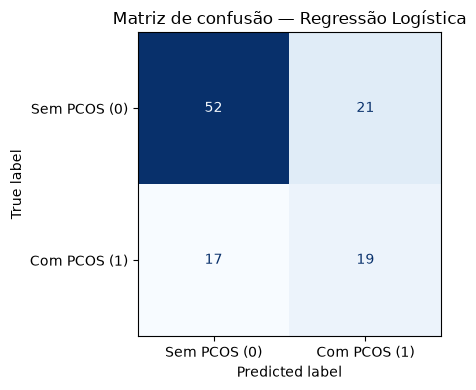

Regressão Logística
  acurácia=0.6514 | recall_pcos=0.5278 | f1_pcos=0.5000


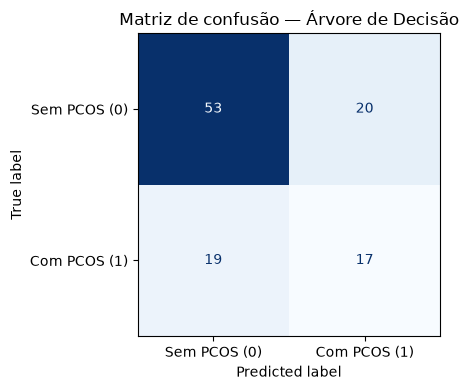

Árvore de Decisão
  acurácia=0.6422 | recall_pcos=0.4722 | f1_pcos=0.4658


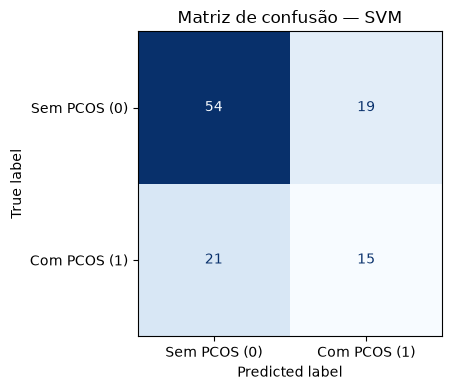

SVM
  acurácia=0.6330 | recall_pcos=0.4167 | f1_pcos=0.4286


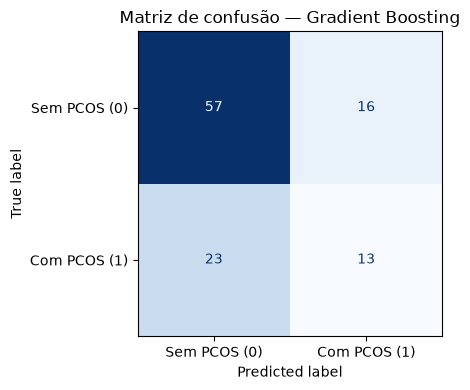

Gradient Boosting
  acurácia=0.6422 | recall_pcos=0.3611 | f1_pcos=0.4000


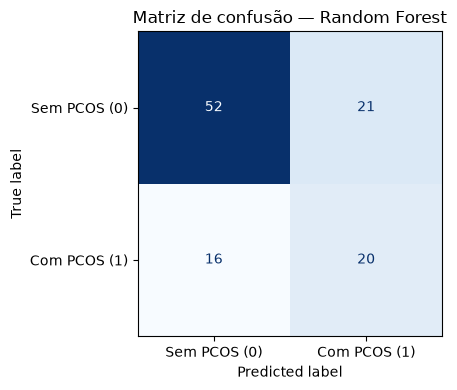

Random Forest
  acurácia=0.6606 | recall_pcos=0.5556 | f1_pcos=0.5195


In [2]:
def slugify(nome: str) -> str:
    mapa = str.maketrans(
        "áàãâäéèêëíìîïóòõôöúùûüçñÁÀÃÂÄÉÈÊËÍÌÎÏÓÒÕÔÖÚÙÛÜÇÑ",
        "aaaaaeeeeiiiiooooouuuucnAAAAAEEEEIIIIOOOOOUUUUCN",
    )
    texto = nome.translate(mapa).lower()
    texto = re.sub(r"[^a-z0-9]+", "_", texto)
    return texto.strip("_")

resultados = {}
caminhos_matrizes = {}

for nome, pipeline in modelos_treinados.items():
    rotulo_previsto = pipeline.predict(atributos_teste)
    relatorio = classification_report(
        rotulo_teste, rotulo_previsto, output_dict=True, zero_division=0
    )
    resultados[nome] = {
        "acuracia": relatorio["accuracy"],
        "recall_pcos": relatorio["1"]["recall"],
        "f1_pcos": relatorio["1"]["f1-score"],
        "precisao_pcos": relatorio["1"]["precision"],
    }

    matriz = confusion_matrix(rotulo_teste, rotulo_previsto)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(
        confusion_matrix=matriz,
        display_labels=["Sem PCOS (0)", "Com PCOS (1)"],
    ).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"Matriz de confusão — {nome}")
    fig.tight_layout()

    caminho_fig = PASTA_FIGURAS / f"matriz_confusao_{slugify(nome)}.png"
    fig.savefig(caminho_fig, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(fig)

    caminhos_matrizes[nome] = str(caminho_fig)
    print(f"{nome}")
    print(
        f"  acurácia={resultados[nome]['acuracia']:.4f} | "
        f"recall_pcos={resultados[nome]['recall_pcos']:.4f} | "
        f"f1_pcos={resultados[nome]['f1_pcos']:.4f}"
    )


## 3 - Melhor modelo (maior recall de PCOS)


In [3]:
nome_melhor = max(resultados, key=lambda n: resultados[n]["recall_pcos"])
metricas_melhor = resultados[nome_melhor]

print(f"Melhor modelo: {nome_melhor}")
print(
    f"  acurácia={metricas_melhor['acuracia']:.4f} | "
    f"recall_pcos={metricas_melhor['recall_pcos']:.4f} | "
    f"f1_pcos={metricas_melhor['f1_pcos']:.4f}"
)


Melhor modelo: Random Forest
  acurácia=0.6606 | recall_pcos=0.5556 | f1_pcos=0.5195


## 4 - Salvar métricas e artefato atualizado


In [4]:
resultados_saida = {**resultados, "_melhor_modelo": nome_melhor}

caminho_metricas = PASTA_METRICAS / "metricas_teste.json"
with open(caminho_metricas, "w", encoding="utf-8") as f:
    json.dump(resultados_saida, f, indent=2, ensure_ascii=False)

pacote_atualizado = {**pacote, "nome_melhor_modelo": nome_melhor}
joblib.dump(pacote_atualizado, PASTA_ARTEFATOS / "modelos_treinados.joblib")

print("Métricas:", caminho_metricas)
print("Artefato:", PASTA_ARTEFATOS / "modelos_treinados.joblib")


Métricas: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\polycystic-ovary-syndrome-pcos\04-avaliacao-metricas\metrics\metricas_teste.json
Artefato: E:\_git\fiap\fase1\tech-challenge-fase1\src\db\outputs\polycystic-ovary-syndrome-pcos\04-avaliacao-metricas\artifacts\modelos_treinados.joblib


## 5 - Discussão

Priorizamos **recall de PCOS (classe 1)** para reduzir falsos negativos em triagem.
Com poucos biomarcadores, o desempenho pode ser limitado — AMH costuma ser o principal sinal.


In [5]:
assert (PASTA_METRICAS / "metricas_teste.json").exists()
assert len(caminhos_matrizes) >= 2
with open(PASTA_METRICAS / "metricas_teste.json", encoding="utf-8") as f:
    metricas_lidas = json.load(f)
assert metricas_lidas["_melhor_modelo"] == nome_melhor
print("Validação OK — melhor modelo:", nome_melhor)


Validação OK — melhor modelo: Random Forest
